In [1]:
# Read in the dataset

import pandas as pd
import numpy as np

df = pd.read_parquet("modelling_dataset.parquet", engine="fastparquet")
df_filtered = df[(df['Zone_Int_ID'] == 0) & (df['Day_of_Week'] == 1) & (df['Month'] == 6) & (df['Year'] == 2016) &  (df['Time_Stamp'].dt.date.astype(str) == '2016-06-21')].sort_values(by='Hour')

df_filtered

,Time_Stamp,Year,Hour,Day_of_Week,Month,Weekend,Holiday,Zone_Int_ID,Amenity,Crossing,...,Wind_Speed(mph),Precipitation(in),Weather_Clear,Weather_Cloudy,Weather_Dust/Windy,Weather_Rain/Drizzle,Weather_Snow/Ice,Weather_Stormy,Weather_Visibility Issues,Accident_Count
6512,2016-06-21 00:00:00,2016,0,1,6,0,0,0,0.041169,0.233068,...,10.400000,0.000000,0.000000,1.000000,0.0,0.000,0.0,0.0,0.0,0
6600,2016-06-21 02:00:00,2016,2,1,6,0,0,0,0.041169,0.233068,...,10.400000,0.000000,0.000000,1.000000,0.0,0.000,0.0,0.0,0.0,0
6688,2016-06-21 04:00:00,2016,4,1,6,0,0,0,0.041169,0.233068,...,10.400000,0.000000,0.000000,1.000000,0.0,0.000,0.0,0.0,0.0,0
6776,2016-06-21 06:00:00,2016,6,1,6,0,0,0,0.041169,0.233068,...,10.400000,0.000000,0.000000,1.000000,0.0,0.000,0.0,0.0,0.0,0
6864,2016-06-21 08:00:00,2016,8,1,6,0,0,0,0.041169,0.233068,...,3.720000,0.000000,0.000000,1.000000,0.0,0.000,0.0,0.0,0.0,2
6952,2016-06-21 10:00:00,2016,10,1,6,0,0,0,0.041169,0.233068,...,4.416667,0.000000,0.166667,0.833333,0.0,0.000,0.0,0.0,0.0,1
7040,2016-06-21 12:00:00,2016,12,1,6,0,0,0,0.041169,0.233068,...,5.033333,0.000000,0.000000,1.000000,0.0,0.000,0.0,0.0,0.0,0
7128,2016-06-21 14:00:00,2016,14,1,6,0,0,0,0.041169,0.233068,...,10.572727,0.023636,0.000000,1.000000,0.0,0.000,0.0,0.0,0.0,1
7216,2016-06-21 16:00:00,2016,16,1,6,0,0,0,0.041169,0.233068,...,6.625000,0.003750,0.375000,0.500000,0.0,0.125,0.0,0.0,0.0,0
7304,2016-06-21 18:00:00,2016,18,1,6,0,0,0,0.041169,0.233068,...,6.130000,0.000000,0.500000,0.500000,0.0,0.000,0.0,0.0,0.0,1


In [ ]:
df.info()

In [ ]:
print(df.columns)


In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm 
from sklearn.preprocessing import StandardScaler

# Sort by time
df = df[df['Time_Stamp'].dt.year >= 2023].copy()
df = df.sort_values('Time_Stamp').reset_index(drop=True)

# Find index thresholds for 70% and 85%
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

# Create the splits
train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

print(f"Train Period:    {train_df['Time_Stamp'].min()} to {train_df['Time_Stamp'].max()}")
print(f"Validation Period:    {val_df['Time_Stamp'].min()} to {val_df['Time_Stamp'].max()}")
print(f"Test Period:    {test_df['Time_Stamp'].min()} to {test_df['Time_Stamp'].max()}")

feature_cols = ['Year', 'Hour', 'Day_of_Week', 'Month', 'Weekend',
    'Holiday', 'Zone_Int_ID', 'Amenity', 'Crossing', 'Give_Way', 'Junction',
    'Railway', 'Station', 'Stop', 'Traffic_Signal', 'Temperature(F)', 
    'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 
    'Precipitation(in)', 'Weather_Clear', 'Weather_Cloudy', 'Weather_Dust/Windy',
    'Weather_Rain/Drizzle', 'Weather_Snow/Ice', 'Weather_Stormy',
    'Weather_Visibility Issues'
]

X_train, y_train = train_df[feature_cols].astype(float), train_df['Accident_Count']
X_val, y_val = val_df[feature_cols].astype(float), val_df['Accident_Count']
X_test, y_test = val_df[feature_cols].astype(float), val_df['Accident_Count']

# Scaling - Fitting only on train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Intercept
X_train_const = sm.add_constant(X_train_scaled, has_constant='add')
X_val_const   = sm.add_constant(X_val_scaled, has_constant='add')
X_test_const  = sm.add_constant(X_test_scaled, has_constant='add')

# Fit model
model = sm.GLM(y_train, X_train_const, family=sm.families.NegativeBinomial(alpha=0.1))
results = model.fit()

# Check for Overfitting
train_pred = results.predict(X_train_const)
val_pred   = results.predict(X_val_const)

print(f"Train Mean Absolute Error: {np.mean(np.abs(y_train - train_pred)):.5f}")
print(f"Val Mean Absolute Error:   {np.mean(np.abs(y_val - val_pred)):.5f}")

print(results.summary())

Train Period:    2023-01-01 00:00:00 to 2023-03-03 20:00:00
Validation Period:    2023-03-03 20:00:00 to 2023-03-17 02:00:00
Test Period:    2023-03-17 02:00:00 to 2023-03-30 08:00:00
Train Mean Absolute Error: 26581503551723253268480.00000
Val Mean Absolute Error:   0.00008
                 Generalized Linear Model Regression Results                  
Dep. Variable:         Accident_Count   No. Observations:               117346
Model:                            GLM   Df Residuals:                   117320
Model Family:        NegativeBinomial   Df Model:                           25
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -79789.
Date:                Fri, 27 Mar 2026   Deviance:                   1.4928e+05
Time:                        20:46:57   Pearson chi2:                 2.06e+05
No. Iterations:                   100   Pseudo R-squ. (CS):             -1.295
Covariance Ty

/tmp/ipykernel_13514/1439306788.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette='viridis')


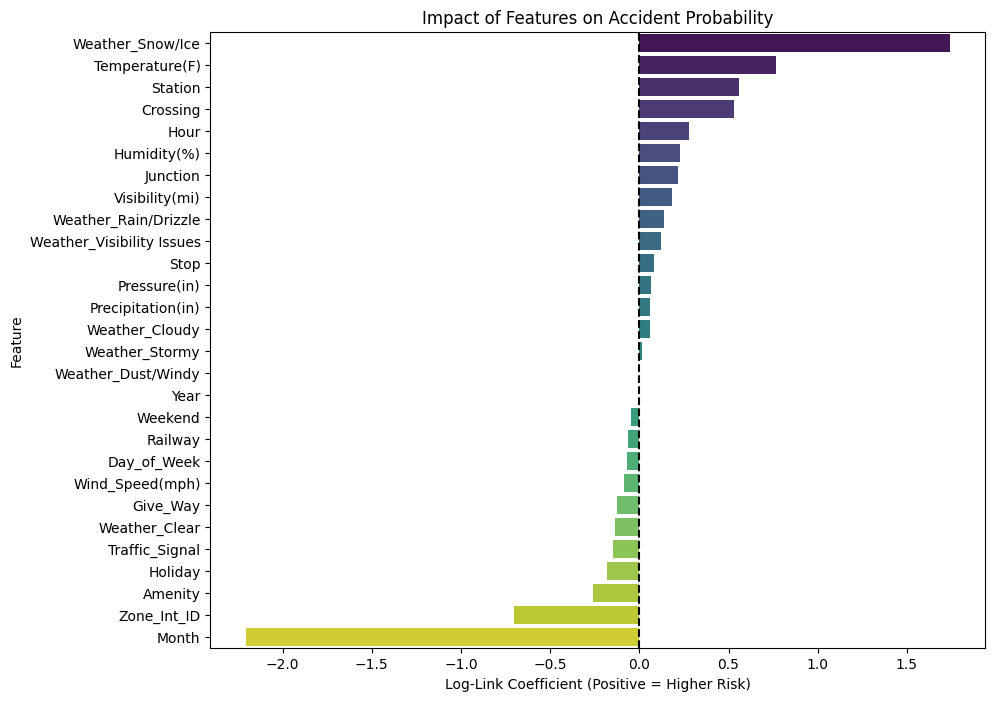

In [3]:
# Create a mapping of names to coefficients
# (Excluding 'const' which is row 0)
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': results.params[1:] 
}).sort_values(by='Coefficient', ascending=False)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette='viridis')
plt.title('Impact of Features on Accident Probability')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel('Log-Link Coefficient (Positive = Higher Risk)')
plt.show()